In [14]:
# Import pandas library (used for data analysis)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [15]:
transactions = pd.read_excel('QVI_transaction_data.xlsx') # Load transaction data
customers = pd.read_csv('QVI_purchase_behaviour.csv')    # Load customer data

In [16]:
print(transactions.head())  # Show first 5 rows of transaction data
print(customers.head())     # Show first 5 rows of customer data


    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  
   LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0            1000   YOUNG SINGLES/COUPLES          Premium
1            1002   YOUNG SINGLES/COUPLES       Mainstream
2            1003          YOUNG FAMILIES           Budget
3            1004  

In [17]:
# Merge transaction + customer data using customer ID
data = pd.merge(transactions, customers, on='LYLTY_CARD_NBR', how='left')

print(data.head())  # Check merged data


    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  \
0    Natural Chip        Compny SeaSalt175g         2        6.0   
1                  CCs Nacho Cheese    175g         3        6.3   
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9   
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0   
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8   

                LIFESTAGE PREMIUM_CUSTOMER  
0   YOUNG SINGLES/COUPLES          Premium  
1  MIDAGE SINGLES/COUPLES           Budget  
2  MIDAGE SINGLES/COUPLES           Budget  
3  MIDAGE SINGLES/COUPLES           Budget  
4  MIDAGE SINGLES/COUPL

In [18]:
# Remove rows with negative or zero sales
data = data[data["TOT_SALES"] > 0]

# Remove rows with invalid product quantity
data = data[data["PROD_QTY"] > 0]

In [19]:
# Group data by customer life stage and sum total sales
life_stage = data.groupby('LIFESTAGE')['TOT_SALES'].sum().sort_values(ascending=False)

print("Sales by Life Stage:\n", life_stage)


Sales by Life Stage:
 LIFESTAGE
OLDER SINGLES/COUPLES     402420.75
RETIREES                  366470.90
OLDER FAMILIES            353767.20
YOUNG FAMILIES            316160.10
YOUNG SINGLES/COUPLES     260405.30
MIDAGE SINGLES/COUPLES    184751.30
NEW FAMILIES               50433.45
Name: TOT_SALES, dtype: float64


In [20]:
# Group data by customer type (Budget, Mainstream, Premium)
customer = data.groupby('PREMIUM_CUSTOMER')['TOT_SALES'].sum().sort_values(ascending=False)

print("\nSales by Customer Type:\n", customer)



Sales by Customer Type:
 PREMIUM_CUSTOMER
Mainstream    750744.50
Budget        676211.55
Premium       507452.95
Name: TOT_SALES, dtype: float64


In [21]:
# Extract brand name from product name (first word)
data["BRAND"] = data["PROD_NAME"].str.split().str[0]




In [22]:
# Find total sales for each brand
brand = data.groupby("BRAND")["TOT_SALES"].sum().sort_values(ascending=False)

print("\nTop 10 Brands:\n", brand.head(10))




Top 10 Brands:
 BRAND
Kettle       390239.8
Smiths       210070.8
Doritos      201538.9
Pringles     177655.5
Old           90785.1
Thins         88852.5
Twisties      81522.1
Tostitos      79789.6
Infuzions     76247.6
Cobs          70569.8
Name: TOT_SALES, dtype: float64


In [23]:
# Extract numeric pack size from product name (e.g., 175g → 175)
data["PACK_SIZE"] = data["PROD_NAME"].str.extract(r'(\d+)').astype(float)


In [24]:
# Find total sales for each pack size
pack = data.groupby("PACK_SIZE")["TOT_SALES"].sum().sort_values(ascending=False)

print("\nTop Pack Sizes:\n", pack.head(10))




Top Pack Sizes:
 PACK_SIZE
175.0    485431.4
150.0    304288.5
134.0    177655.5
110.0    162765.4
170.0    146673.0
330.0    136794.3
300.0    113330.6
165.0    101360.6
380.0     76719.6
270.0     55425.4
Name: TOT_SALES, dtype: float64


In [28]:
# Create sales data
sales = data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"].sum()



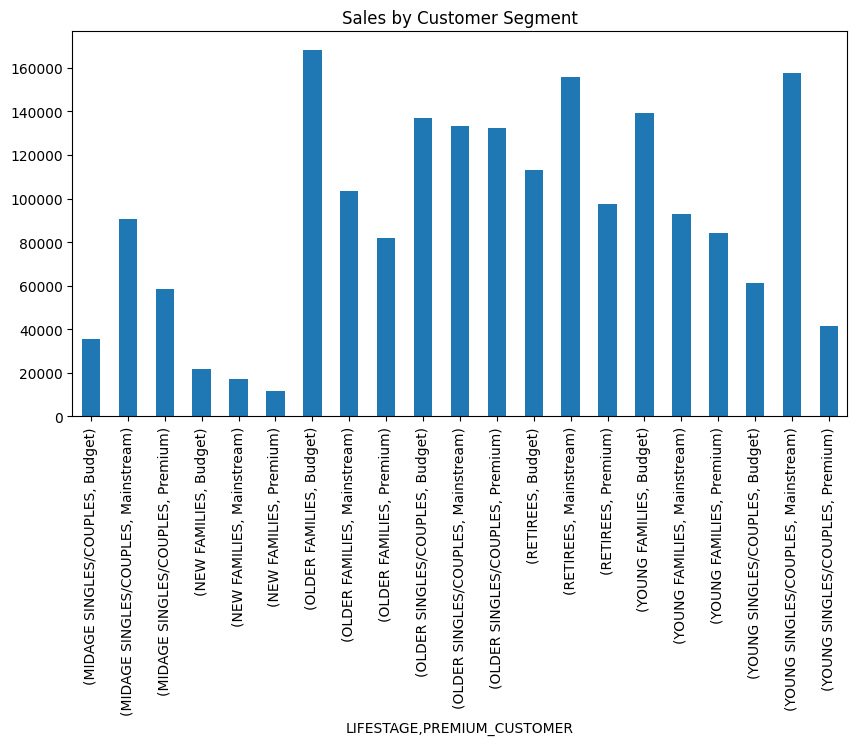

In [29]:
sales.plot(kind="bar", figsize=(10,5))
plt.title("Sales by Customer Segment")
plt.show()

In [30]:
# FINAL INSIGHTS

print("1. Highest sales come from Budget Older Families and Mainstream Young Singles.")
print("2. Families buy more units per customer.")
print("3. Mainstream customers pay higher price per unit.")
print("4. Young Singles/Couples are the most valuable segment.")
print("5. Recommend targeting this segment with premium products.")

1. Highest sales come from Budget Older Families and Mainstream Young Singles.
2. Families buy more units per customer.
3. Mainstream customers pay higher price per unit.
4. Young Singles/Couples are the most valuable segment.
5. Recommend targeting this segment with premium products.
